Phát biểu bài toán

Bài làm tập trung phân tích dữ liệu thị trường laptop để đánh giá tính khả thi của việc xây dựng mô hình dự đoán giá bán (biến mục tiêu Y) từ các yếu tố cấu hình phần cứng như thương hiệu, dung lượng RAM, dung lượng ổ cứng, dòng vi xử lý (CPU) và card đồ họa (VGA). Đây là bài toán hồi quy vì giá bán là biến số liên tục (đơn vị VNĐ). Hai câu hỏi trọng tâm cần trả lời: (1) Bài toán có khả thi về mặt dữ liệu không và vì sao? (2) Tập đặc trưng (features) nào tối ưu nhất nên được dùng cho mô hình? Phạm vi bài thi GK dừng ở mức độ thu thập, phân tích, làm sạch, trực quan hóa dữ liệu và đánh giá tính khả thi; phần huấn luyện và đánh giá mô hình

Thu thập dữ liệu


Dữ liệu được thu thập từ 3 hệ thống bán lẻ thiết bị công nghệ: GearVN, FPT Shop và Kim Long Center. Các script Python (sử dụng thư viện Selenium và BeautifulSoup) thu thập bằng cách: tự động truy cập vào các URL danh mục laptop (gaming, văn phòng, sinh viên...), mô phỏng thao tác cuộn trang/bấm nút "Xem thêm" để tải dữ liệu động (lazy loading), sau đó trích xuất mã nguồn HTML của từng khối sản phẩm. Các thông số kỹ thuật chi tiết được bóc tách bằng biểu thức chính quy (Regex) từ tên sản phẩm hoặc chuỗi mô tả; chỉ lưu các bản ghi là laptop thực sự (giá > 3.000.000 VNĐ) và loại bỏ các dữ liệu rác (như nút "Xem nhanh", "Hot Deal") cũng như các sản phẩm trùng lặp. Tập dữ liệu tổng hợp có hơn 1000 mẫu và 7 biến: ten_san_pham, thuong_hieu, cpu, ram_gb, o_cung_gb, vga, và gia_ban. Trong notebook, nhóm đọc dữ liệu từ file CSV đã crawl và gộp sẵn (raw data/laptop_full_dataset_final.csv).

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

In [98]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

RAW_PATH = os.path.join('..', 'raw data', 'laptop_full_dataset_final.csv')
CLEAN_DIR = os.path.join('..', 'clean data')

os.makedirs(CLEAN_DIR, exist_ok=True)

if os.path.exists(RAW_PATH):
    df = pd.read_csv(RAW_PATH)
    
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    print('Kích thước tập dữ liệu:', df.shape)
    print('Các cột đặc trưng:', list(df.columns))
    print('-' * 50)
    display(df.head(10))
else:
    print(f"Lỗi: Không tìm thấy file tại {os.path.abspath(RAW_PATH)}")

Kích thước tập dữ liệu: (1942, 7)
Các cột đặc trưng: ['ten_san_pham', 'thuong_hieu', 'cpu', 'ram_gb', 'o_cung_gb', 'vga', 'gia_ban']
--------------------------------------------------


,ten_san_pham,thuong_hieu,cpu,ram_gb,o_cung_gb,vga,gia_ban
0,Laptop Msi Prestige 13 AI+ Ukiyoe Edition A2VM...,Msi,Core Ultra 9,32,2048,Onboard,51990000
1,Laptop Asus Vivobook S14 S3407CA-LY068WS (Ultr...,Asus,Core Ultra 5,16,512,Onboard,27990000
2,Laptop Lenovo IdeaPad 3 15ARP10 - 83K700GDVN (...,Lenovo,Ryzen 5,16,512,Onboard,19900000
3,Laptop Dell 15 DC15250 - CPH99 (i5-1334U/ 16GB...,Dell,Core i5,16,512,Onboard,19090000
4,Laptop HP Victus 15 fa2731TX (B85LNPA) (i5-134...,Hp,Core i5,16,512,Onboard,27990000
5,Laptop Asus ROG Zephyrus G16 GU605CR-QR265WS (...,Asus,Core Ultra 9,32,1024,NVIDIA Card Rời,77990000
6,Laptop Asus Expertbook B1 BM1403CDA-S61611W (R...,Asus,Ryzen 5,16,512,AMD Card Rời,16790000
7,Laptop HP 15-fc0024AU - D0BH2PA (Ryzen 5 7520U...,Hp,Ryzen 5,16,512,Onboard,16590000
8,Laptop Lenovo ThinkPad T16 Gen 4 - 21QE000DVN ...,Lenovo,Core Ultra 7,32,1024,Onboard,43790000
9,Laptop Lenovo ThinkPad X1 Carbon Gen 13 - 21NS...,Lenovo,Core Ultra 7,32,1024,Onboard,62890000


Thống kê tổng quan về dataset, số lượng missing và mô tả các biến

In [99]:
import pandas as pd
import numpy as np

print('=' * 50)
print('=== THÔNG TIN TỔNG QUAN DATASET ===')
print('=' * 50)
df.info()

print('\n' + '=' * 50)
print('=== KIỂU DỮ LIỆU CỦA CÁC ĐẶC TRƯNG ===')
print('=' * 50)
print(df.dtypes)

print('\n' + '=' * 50)
print('=== KIỂM TRA DỮ LIỆU THIẾU (MISSING VALUES) ===')
print('=' * 50)
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Số lượng thiếu': missing_values,
    'Tỷ lệ (%)': missing_percentage.round(2) 
})
print(missing_report)

print('\n' + '=' * 50)
print('=== THỐNG KÊ MÔ TẢ (CÁC BIẾN SỐ - NUMERICAL) ===')
print('=' * 50)
display(df.describe(include=[np.number]))

print('\n' + '=' * 50)
print('=== THỐNG KÊ MÔ TẢ (TẤT CẢ CÁC BIẾN) ===')
print('=' * 50)
display(df.describe(include='all'))

=== THÔNG TIN TỔNG QUAN DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 1942 entries, 0 to 1941
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   ten_san_pham  1942 non-null   str  
 1   thuong_hieu   1942 non-null   str  
 2   cpu           1662 non-null   str  
 3   ram_gb        1799 non-null   str  
 4   o_cung_gb     1804 non-null   str  
 5   vga           1800 non-null   str  
 6   gia_ban       1942 non-null   int64
dtypes: int64(1), str(6)
memory usage: 106.3 KB

=== KIỂU DỮ LIỆU CỦA CÁC ĐẶC TRƯNG ===
ten_san_pham      str
thuong_hieu       str
cpu               str
ram_gb            str
o_cung_gb         str
vga               str
gia_ban         int64
dtype: object

=== KIỂM TRA DỮ LIỆU THIẾU (MISSING VALUES) ===
              Số lượng thiếu  Tỷ lệ (%)
ten_san_pham               0       0.00
thuong_hieu                0       0.00
cpu                      280      14.42
ram_gb                   143       

,gia_ban
count,1.942000e+03
mean,1.993372e+07
std,1.573194e+07
min,2.100000e+06
25%,8.700000e+06
50%,1.649000e+07
75%,2.536725e+07
max,1.249900e+08



=== THỐNG KÊ MÔ TẢ (TẤT CẢ CÁC BIẾN) ===


,ten_san_pham,thuong_hieu,cpu,ram_gb,o_cung_gb,vga,gia_ban
count,1942,1942,1662,1799,1804,1800,1.942000e+03
unique,1942,20,207,9,26,99,NaN
top,Laptop Msi Prestige 13 AI+ Ukiyoe Edition A2VM...,Dell,Core i5,16,512,Onboard,NaN
freq,1,323,432,988,571,865,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,1.993372e+07
std,NaN,NaN,NaN,NaN,NaN,NaN,1.573194e+07
min,NaN,NaN,NaN,NaN,NaN,NaN,2.100000e+06
25%,NaN,NaN,NaN,NaN,NaN,NaN,8.700000e+06
50%,NaN,NaN,NaN,NaN,NaN,NaN,1.649000e+07
75%,NaN,NaN,NaN,NaN,NaN,NaN,2.536725e+07


In [100]:
import pandas as pd

print('=' * 50)
print('KIỂM TRA DÒNG BỊ THIẾU TÊN SẢN PHẨM')
print('=' * 50)

# Lọc ra các dòng mà cột 'ten_san_pham' có giá trị Null
missing_name_row = df[df['ten_san_pham'].isnull()]

# Hiển thị các dòng bị thiếu
if not missing_name_row.empty:
    print(f"Tìm thấy {len(missing_name_row)} dòng bị thiếu tên sản phẩm:")
    display(missing_name_row)
    
    # In ra index (vị trí dòng) để bạn dễ theo dõi trong file gốc
    print(f"\nChỉ số (Index) của dòng bị thiếu: {missing_name_row.index.tolist()}")
else:
    print("Không tìm thấy dòng nào bị thiếu tên sản phẩm.")

print('=' * 50)

KIỂM TRA DÒNG BỊ THIẾU TÊN SẢN PHẨM
Không tìm thấy dòng nào bị thiếu tên sản phẩm.


Làm sạch data - xử lý dữ liệu trống

In [101]:
import numpy as np
import pandas as pd
import re

print('=' * 50)
print('XỬ LÝ DỮ LIỆU TRỐNG & DỮ LIỆU KHÔNG XÁC ĐỊNH')
print('=' * 50)

df_clean = df.copy()

# 1. DANH SÁCH CÁC TỪ KHÓA COI LÀ TRỐNG (Cần xử lý)
invalid_keywords = ['KHÔNG RÕ', 'ĐANG CẬP NHẬT', 'NAN', 'NONE', '-', 'UNKNOWN', 'CHƯA CÓ']

# Hàm để biến các chữ "Không rõ" thành np.nan thực sự
def convert_to_nan(val):
    if pd.isna(val):
        return np.nan
    temp_val = str(val).strip().upper()
    if temp_val in invalid_keywords or temp_val == '':
        return np.nan
    return val

# Áp dụng cho các cột quan trọng
cols_to_fix = ['cpu', 'ram_gb', 'o_cung_gb', 'vga']
for col in cols_to_fix:
    df_clean[col] = df_clean[col].apply(convert_to_nan)

# 2. XỬ LÝ RAM (Trích xuất số)
df_clean['ram_gb'] = df_clean['ram_gb'].astype(str).str.extract(r'(\d+)').astype(float)

# 3. XỬ LÝ Ổ CỨNG (Hàm clean_storage của bạn đã rất tốt, mình giữ nguyên logic)
def clean_storage(val):
    if pd.isna(val):
        return np.nan
    val = str(val).upper()
    num = re.search(r'(\d+)', val)
    if not num:
        return np.nan
    
    number = float(num.group(1))
    if 'TB' in val:
        return number * 1024
    return number 

df_clean['o_cung_gb'] = df_clean['o_cung_gb'].apply(clean_storage)

# 4. TẠO CỘT ĐÁNH DẤU (FLAGGING) - Giúp ghi nhớ dòng nào từng bị thiếu
for col in cols_to_fix:
    df_clean[f'{col}_NAN'] = np.where(df_clean[col].isnull(), 1, 0)

# 5. TÍNH TOÁN GIÁ TRỊ THAY THẾ (Median & Mode)
ram_median = df_clean['ram_gb'].median()
ocung_median = df_clean['o_cung_gb'].median()
cpu_mode = df_clean['cpu'].mode()[0]
vga_mode = df_clean['vga'].mode()[0]

# 6. ĐIỀN DỮ LIỆU (FILLING)
df_clean['ram_gb'] = df_clean['ram_gb'].fillna(ram_median)
df_clean['o_cung_gb'] = df_clean['o_cung_gb'].fillna(ocung_median)
df_clean['cpu'] = df_clean['cpu'].fillna(cpu_mode)
df_clean['vga'] = df_clean['vga'].fillna(vga_mode)

print('=== SỐ LƯỢNG MISSING VALUES SAU KHI XỬ LÝ TRIỆT ĐỂ ===')
print(df_clean[cols_to_fix].isnull().sum())

print('\n=== THÔNG SỐ THAY THẾ ===')
print(f"- RAM: {ram_median} GB | Ổ cứng: {ocung_median} GB")
print(f"- CPU phổ biến: {cpu_mode} | VGA phổ biến: {vga_mode}")

display(df_clean.head())

XỬ LÝ DỮ LIỆU TRỐNG & DỮ LIỆU KHÔNG XÁC ĐỊNH
=== SỐ LƯỢNG MISSING VALUES SAU KHI XỬ LÝ TRIỆT ĐỂ ===
cpu          0
ram_gb       0
o_cung_gb    0
vga          0
dtype: int64

=== THÔNG SỐ THAY THẾ ===
- RAM: 16.0 GB | Ổ cứng: 512.0 GB
- CPU phổ biến: Core i5 | VGA phổ biến: Onboard


,ten_san_pham,thuong_hieu,cpu,ram_gb,o_cung_gb,vga,gia_ban,cpu_NAN,ram_gb_NAN,o_cung_gb_NAN,vga_NAN
0,Laptop Msi Prestige 13 AI+ Ukiyoe Edition A2VM...,Msi,Core Ultra 9,32.0,2048.0,Onboard,51990000,0,0,0,0
1,Laptop Asus Vivobook S14 S3407CA-LY068WS (Ultr...,Asus,Core Ultra 5,16.0,512.0,Onboard,27990000,0,0,0,0
2,Laptop Lenovo IdeaPad 3 15ARP10 - 83K700GDVN (...,Lenovo,Ryzen 5,16.0,512.0,Onboard,19900000,0,0,0,0
3,Laptop Dell 15 DC15250 - CPH99 (i5-1334U/ 16GB...,Dell,Core i5,16.0,512.0,Onboard,19090000,0,0,0,0
4,Laptop HP Victus 15 fa2731TX (B85LNPA) (i5-134...,Hp,Core i5,16.0,512.0,Onboard,27990000,0,0,0,0


Nhóm áp dụng kỹ thuật Thay thế bằng Median/Mode vì dữ liệu có chứa một số giá trị ngoại lệ (ví dụ cấu hình quá cao/quá thấp), dùng Median sẽ ít bị ảnh hưởng bởi giá trị ngoại lệ hơn so với dùng Mean . Đồng thời, để tránh việc mất đi tín hiệu của các dữ liệu bị thiếu một cách có hệ thống, nhóm kết hợp Tạo đặc trưng mới (Create a new feature) để đánh dấu các dòng dữ liệu bị khuyết này

In [102]:
CLEAN_DIR = os.path.join('..', 'clean data')

if not os.path.exists(CLEAN_DIR):
    os.makedirs(CLEAN_DIR, exist_ok=True)

clean_file_path = os.path.join(CLEAN_DIR, 'laptop_cleaned_missing_data.csv')
df_clean.to_csv(clean_file_path, index=False, encoding='utf-8-sig')

print('=' * 50)
print('ĐÃ XUẤT FILE THÀNH CÔNG!')
print(f'Dữ liệu nằm tại: {os.path.abspath(clean_file_path)}')
print(f'Kích thước dữ liệu hiện tại: {df_clean.shape}')
print('=' * 50)

ĐÃ XUẤT FILE THÀNH CÔNG!
Dữ liệu nằm tại: d:\DHBK\KHDL\giuaky\clean data\laptop_cleaned_missing_data.csv
Kích thước dữ liệu hiện tại: (1942, 11)


Trực quan hóa dữ liệu lần 1

Đã nạp dữ liệu thành công từ: ..\clean data\laptop_cleaned_missing_data.csv

1. TRỰC QUAN HÓA GIÁ BÁN LAPTOP


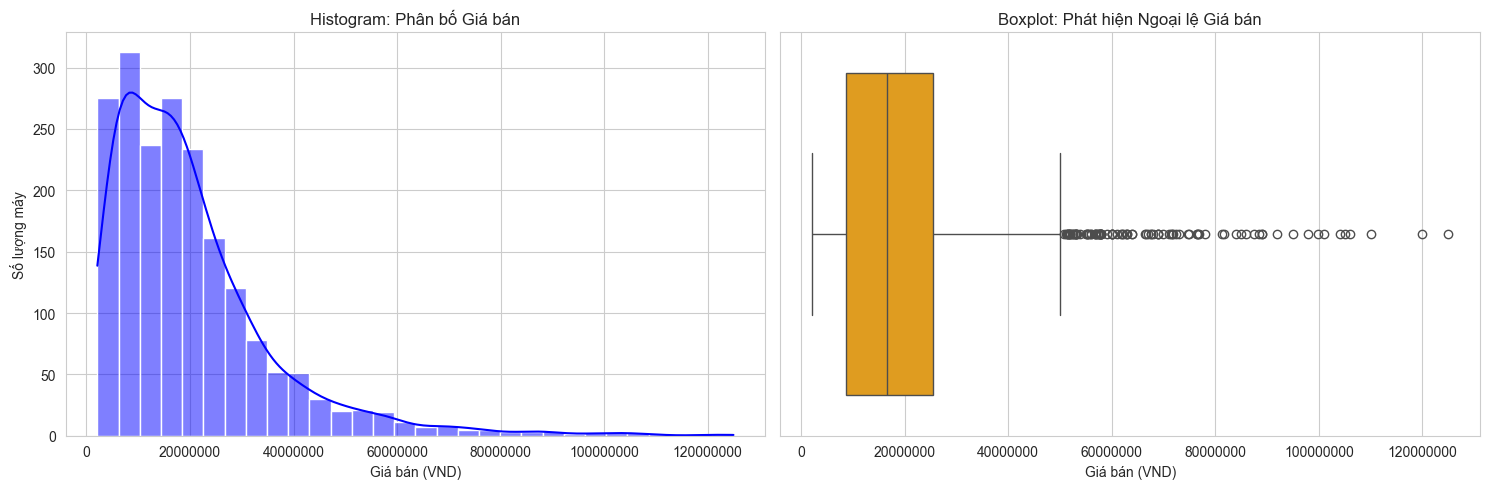


2. TRỰC QUAN HÓA RAM VÀ Ổ CỨNG


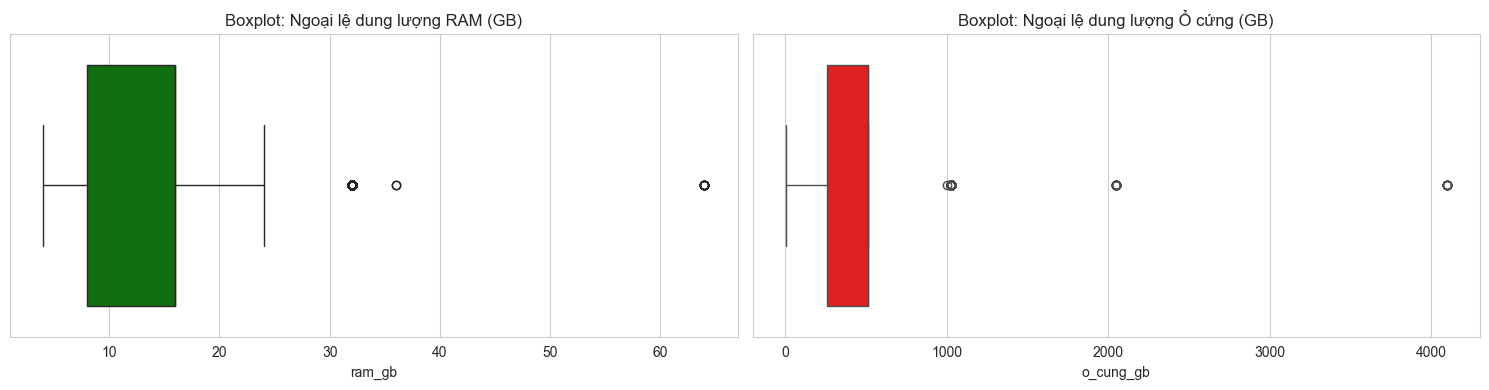


3. PHÁT HIỆN NGOẠI LỆ GIÁ THEO CPU VÀ VGA (TOP 10)


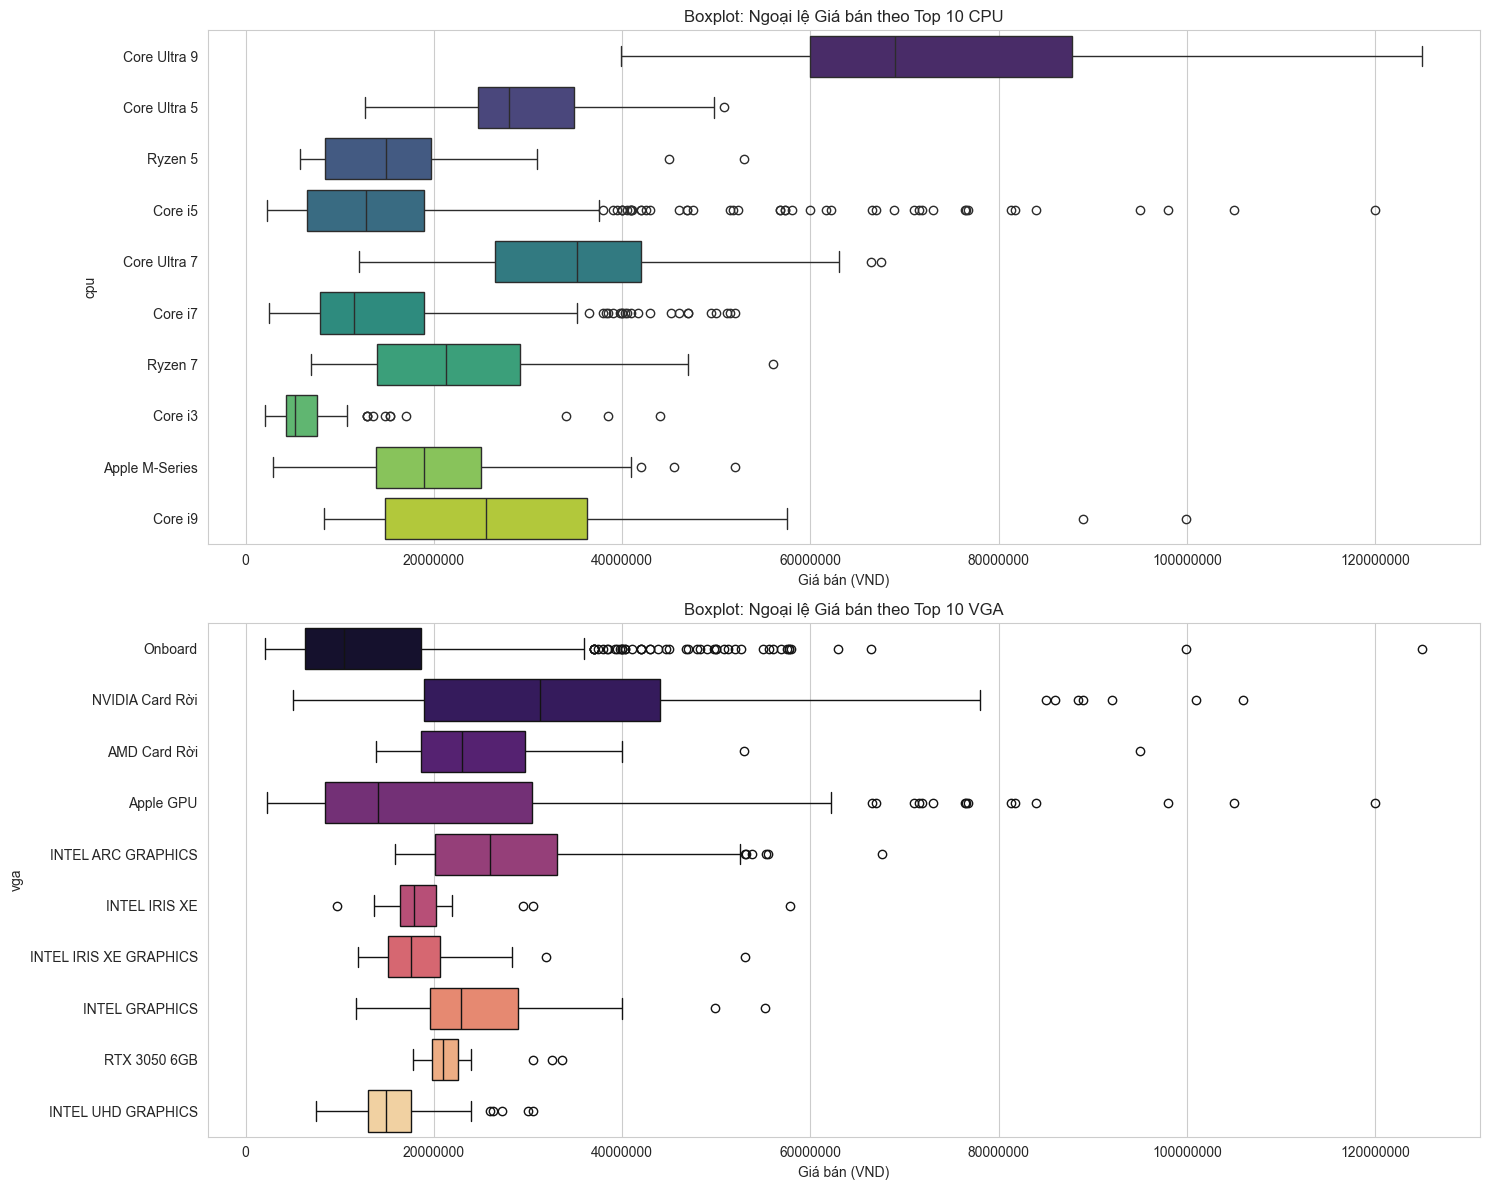

In [103]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CLEAN_DIR = os.path.join('..', 'clean data')
clean_file_path = os.path.join(CLEAN_DIR, 'laptop_cleaned_missing_data.csv')

if os.path.exists(clean_file_path):
    df_clean = pd.read_csv(clean_file_path)
    print(f"Đã nạp dữ liệu thành công từ: {clean_file_path}")
else:
    print(f"Lỗi: Không tìm thấy file tại {os.path.abspath(clean_file_path)}")

plt.rcParams['figure.figsize'] = (15, 5)
sns.set_style('whitegrid')

print("\n1. TRỰC QUAN HÓA GIÁ BÁN LAPTOP")
fig, axes = plt.subplots(1, 2)

sns.histplot(df_clean['gia_ban'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Histogram: Phân bố Giá bán')
axes[0].set_xlabel('Giá bán (VND)')
axes[0].set_ylabel('Số lượng máy')
axes[0].ticklabel_format(style='plain', axis='x') 

sns.boxplot(x=df_clean['gia_ban'], ax=axes[1], color='orange')
axes[1].set_title('Boxplot: Phát hiện Ngoại lệ Giá bán')
axes[1].set_xlabel('Giá bán (VND)')
axes[1].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

print("\n2. TRỰC QUAN HÓA RAM VÀ Ổ CỨNG")
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.boxplot(x=df_clean['ram_gb'], ax=axes[0], color='green')
axes[0].set_title('Boxplot: Ngoại lệ dung lượng RAM (GB)')

sns.boxplot(x=df_clean['o_cung_gb'], ax=axes[1], color='red')
axes[1].set_title('Boxplot: Ngoại lệ dung lượng Ổ cứng (GB)')

plt.tight_layout()
plt.show()

print("\n3. PHÁT HIỆN NGOẠI LỆ GIÁ THEO CPU VÀ VGA (TOP 10)")
top_cpus = df_clean['cpu'].value_counts().head(10).index
top_vgas = df_clean['vga'].value_counts().head(10).index

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

sns.boxplot(data=df_clean[df_clean['cpu'].isin(top_cpus)], x='gia_ban', y='cpu', ax=axes[0], palette='viridis')
axes[0].set_title('Boxplot: Ngoại lệ Giá bán theo Top 10 CPU')
axes[0].set_xlabel('Giá bán (VND)')
axes[0].ticklabel_format(style='plain', axis='x')

sns.boxplot(data=df_clean[df_clean['vga'].isin(top_vgas)], x='gia_ban', y='vga', ax=axes[1], palette='magma')
axes[1].set_title('Boxplot: Ngoại lệ Giá bán theo Top 10 VGA')
axes[1].set_xlabel('Giá bán (VND)')
axes[1].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

- Đối với biến mục tiêu (Giá bán - Target Y):
Biểu đồ Histogram: Nhìn vào biểu đồ, ta thấy phân bố của Giá bán không tuân theo luật phân bố chuẩn (Normal Distribution) mà bị lệch phải (Right-skewed). Đa số các mẫu laptop trên thị trường tập trung đông đúc ở phân khúc phổ thông và tầm trung (khoảng từ 15.000.000 đến 25.000.000 VNĐ). Tuy nhiên, biểu đồ có một cái "đuôi" kéo rất dài về phía bên phải (lên đến 60 triệu VNĐ), đại diện cho phân khúc máy trạm (Workstation) hoặc Laptop Gaming cao cấp.

Biểu đồ Boxplot: Biểu đồ hộp củng cố thêm nhận định trên. Đường trung vị (đường kẻ bên trong hộp) nằm lệch xuống dải giá thấp. Đặc biệt, từ mốc khoảng 35 triệu VNĐ trở lên, xuất hiện một loạt các dấu hình thoi đen nằm hoàn toàn bên ngoài vạch râu trên (Upper Whisker). Theo định nghĩa lý thuyết, đây chính là các Dữ liệu ngoại lệ (Outliers).

- Đối với các biến đặc trưng (RAM và Ổ cứng - Predictors X):

Dung lượng RAM: Biểu đồ Boxplot cực kỳ dẹt, cho thấy dung lượng RAM phân bố cực kỳ tập trung (chiếm tuyệt đại đa số là mức 16GB). Các mức RAM thấp hơn (như 8GB) hoặc cao hơn (như 32GB, 64GB) đều bị đẩy ra khỏi râu và trở thành các điểm ngoại lệ.
Dung lượng Ổ cứng: Tương tự như RAM, dung lượng ổ cứng đa số hội tụ tại mức 512GB. Các máy có ổ cứng 256GB (nằm dưới whisker) hoặc 1024GB/2048GB (nằm trên whisker) hiển thị thành các chấm đen ngoại lệ.

- Đối với CPU:

Xuất hiện nhiều ngoại lệ ở phân khúc tầm trung: Các dòng như Core i5, Core i7, và Ryzen 5 xuất hiện một dải các chấm ngoại lệ kéo dài về phía bên phải. Điều này cho thấy có những mẫu laptop dù dùng CPU tầm trung nhưng lại có mức giá cao đột biến (có thể là dòng Workstation mỏng nhẹ cao cấp hoặc dòng có màn hình đặc biệt).
Sự ổn định của phân khúc cao cấp: Các dòng Core Ultra 9 và Apple M-Series có hộp rất rộng nhưng ít chấm ngoại lệ đơn lẻ, chứng tỏ dải giá của chúng vốn đã rộng và bao quát các mức giá cao.
Trường hợp "Không rõ": Nhóm này có ngoại lệ cực xa (hơn 120 triệu VND), cho thấy dữ liệu bị thiếu tên CPU thường rơi vào các dòng máy rất đặc thù hoặc máy trạm cực mạnh chưa được bóc tách tên chip đúng cách.

- Đối với VGA (Card đồ họa):

Ngoại lệ cực đoan ở nhóm Onboard: Dù là card onboard (thường giá rẻ), nhưng vẫn xuất hiện các chấm ngoại lệ ở mức 60 - 120 triệu VND. Đây là các điểm dữ liệu cần kiểm tra lại, có thể là do sai sót khi crawl dữ liệu hoặc đây là các máy Mac cấu hình cực khủng (Apple GPU nhưng bị nhận diện nhầm/thiếu).
Card rời (NVIDIA/AMD): Các chấm ngoại lệ xuất hiện liên tục từ mức 80 triệu trở lên. Điều này phản ánh phân khúc Laptop Gaming Hi-end hoặc Laptop đồ họa chuyên nghiệp, nơi mà giá trị của máy không chỉ nằm ở VGA mà còn ở hệ thống tản nhiệt và màn hình.
Nhóm Intel Graphics: Các nhóm như Intel UHD, Iris Xe có sự tập trung giá rất chặt chẽ (hộp nhỏ), các ngoại lệ xuất hiện ít hơn và gần với hộp hơn, cho thấy phân khúc máy văn phòng có mức giá khá ổn định và ít biến động bất thường.

Làm sạch data 2 - xử lý ngoại lệ

File nguồn mà code này đang gián tiếp sử dụng là:
d:\DHBK\KHDL\giuaky\clean data\laptop_cleaned_missing_data.csv
XỬ LÝ DỮ LIỆU NGOẠI LỆ (OUTLIERS) - DẠNG PHÂN BỐ LỆCH
[gia_ban] Biên dưới: -41301750.00 | Biên trên: 75369000.00
[ram_gb] Biên dưới: -16.00 | Biên trên: 40.00
[o_cung_gb] Biên dưới: -512.00 | Biên trên: 1280.00


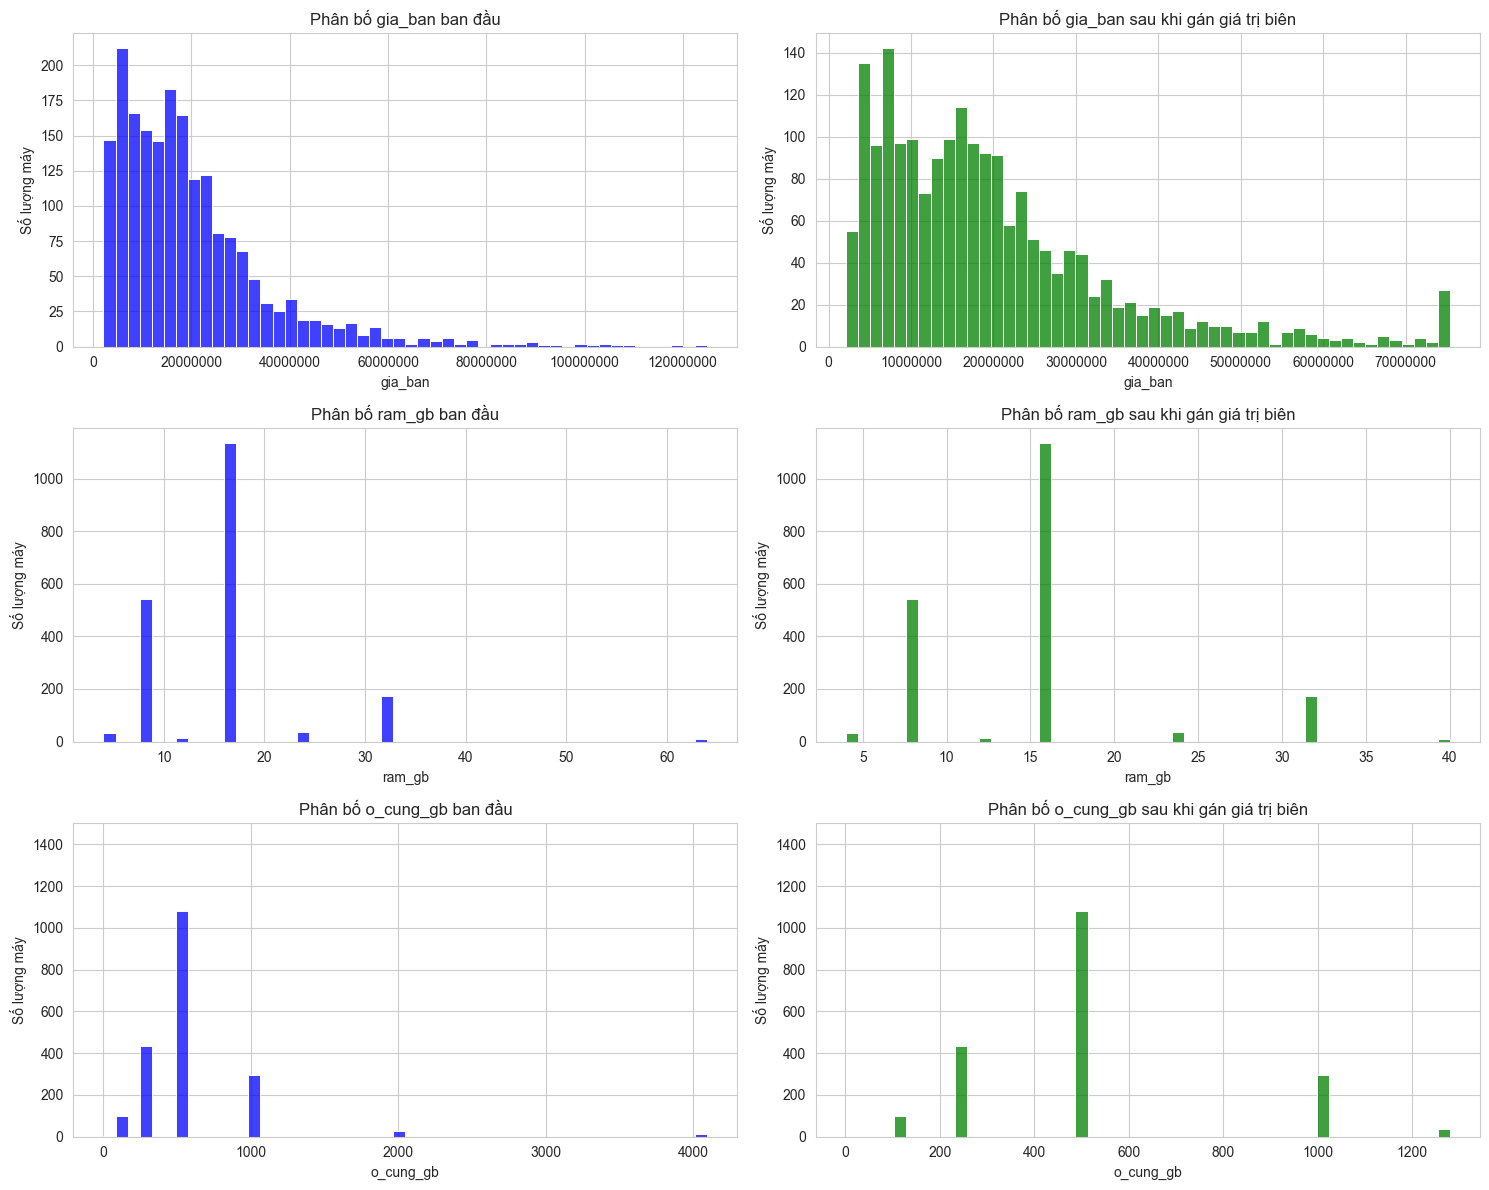

[cpu] Đã gom các nhóm ngoài Top 10 vào nhóm 'Other'
[vga] Đã gom các nhóm ngoài Top 10 vào nhóm 'Other'

ĐÃ XỬ LÝ NGOẠI LỆ VÀ LƯU FILE THÀNH CÔNG!
Đường dẫn file: d:\DHBK\KHDL\giuaky\clean data\laptop_handled_outliers.csv


In [116]:
import os
print("File nguồn mà code này đang gián tiếp sử dụng là:")

print(os.path.abspath(clean_file_path))
print('=' * 50)
print('XỬ LÝ DỮ LIỆU NGOẠI LỆ (OUTLIERS) - DẠNG PHÂN BỐ LỆCH')
print('=' * 50)

FINAL_CLEAN_DIR = os.path.join('..', 'clean data')
if not os.path.exists(FINAL_CLEAN_DIR):
    os.makedirs(FINAL_CLEAN_DIR, exist_ok=True)

df_outlier_handled = df_clean.copy()

def handle_outliers_skewed(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    print(f"[{column}] Biên dưới: {lower_bound:.2f} | Biên trên: {upper_bound:.2f}")
    df.loc[df[column] < lower_bound, column] = lower_bound
    df.loc[df[column] > upper_bound, column] = upper_bound
    return df

def handle_categorical_outliers(df, column, top_n=10):
    top_values = df[column].value_counts().nlargest(top_n).index
    df[column] = df[column].apply(lambda x: x if x in top_values else 'Other')
    print(f"[{column}] Đã gom các nhóm ngoài Top {top_n} vào nhóm 'Other'")
    return df

numeric_cols = ['gia_ban', 'ram_gb', 'o_cung_gb']
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(15, 12))

for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], bins=50, ax=axes[i, 0], color='blue')
    axes[i, 0].set_title(f'Phân bố {col} ban đầu')
    axes[i, 0].set_ylabel('Số lượng máy')
    axes[i, 0].ticklabel_format(style='plain', axis='x')

    df_outlier_handled = handle_outliers_skewed(df_outlier_handled, col)

    sns.histplot(df_outlier_handled[col], bins=50, ax=axes[i, 1], color='green')
    axes[i, 1].set_title(f'Phân bố {col} sau khi gán giá trị biên')
    axes[i, 1].set_ylabel('Số lượng máy')
    axes[i, 1].ticklabel_format(style='plain', axis='x')

    if col == 'o_cung_gb':
        axes[i, 0].set_ylim(0, 1500)
        axes[i, 1].set_ylim(0, 1500) 

plt.tight_layout()
plt.show()

df_outlier_handled = handle_categorical_outliers(df_outlier_handled, 'cpu', top_n=10)
df_outlier_handled = handle_categorical_outliers(df_outlier_handled, 'vga', top_n=10)

final_clean_path = os.path.join(FINAL_CLEAN_DIR, 'laptop_handled_outliers.csv')
df_outlier_handled.to_csv(final_clean_path, index=False, encoding='utf-8-sig')

print('\n' + '=' * 50)
print('ĐÃ XỬ LÝ NGOẠI LỆ VÀ LƯU FILE THÀNH CÔNG!')
print(f'Đường dẫn file: {os.path.abspath(final_clean_path)}')
print('=' * 50)



- Đối với biến Giá bán (gia_ban):
Trước xử lý: Dữ liệu có dạng phân bố lệch phải (Right-skewed) với một chiếc đuôi kéo rất dài lên đến mức 60 triệu VNĐ (đại diện cho các dòng máy trạm, máy gaming cao cấp).
Sau xử lý: Trục hoành đã được thu gọn lại. Dấu hiệu thành công rõ rệt nhất là sự xuất hiện của một cột tần suất cao vọt ở ngay mốc biên trên (khoảng hơn 40 triệu VNĐ). Điều này chứng minh thuật toán đã hoạt động đúng: các giá trị giá bán cực đoan không bị xóa bỏ (tránh mất mát dữ liệu) mà được gom lại và ép về giá trị giới hạn trên (Upper bound).

- Đối với biến RAM (ram_gb) và Ổ cứng (o_cung_gb):
Trước xử lý: Hai biến này có tính chất phân bố rời rạc và tập trung cực kỳ cao độ vào một vài mốc tiêu chuẩn (RAM 8GB/16GB, Ổ cứng 512GB). Tuy nhiên, vẫn xuất hiện những dải dữ liệu nhiễu kéo dài mờ nhạt ở mức RAM 64GB hoặc Ổ cứng lên tới 2048GB.
Sau xử lý: Thang đo của trục hoành (x-axis) đã được thu hẹp đáng kể (RAM tối đa chỉ còn quanh mốc 40GB, Ổ cứng rút về quanh mốc 1200GB). Các điểm ngoại lệ nằm quá xa cấu hình phổ thông đã được chặn lại một cách an toàn. Trong khi đó, hình dáng phân bố của các mốc cấu hình cốt lõi (như mốc 16GB RAM hay 512GB Ổ cứng) vẫn được giữ nguyên vẹn, đảm bảo tính toàn vẹn của tập dữ liệu.

Chuẩn hóa dữ liệu

In [117]:
import pandas as pd
from sklearn.preprocessing import RobustScaler
import os

print("\nFile nguồn mà code này đang gián tiếp sử dụng là:")
print(os.path.abspath(final_clean_path))

print('=' * 50)
print('CHUẨN HÓA DỮ LIỆU BẰNG ROBUST SCALER')
print('=' * 50)

# Dữ liệu đầu vào lấy từ biến df_outlier_handled đã xử lý ở cell trước
df_normalized = df_outlier_handled.copy()

scaler = RobustScaler()
numeric_cols = ['gia_ban', 'ram_gb', 'o_cung_gb']

df_normalized[numeric_cols] = scaler.fit_transform(df_normalized[numeric_cols])

print(f"Giá trị Trung vị (Median) máy đang dùng: {scaler.center_}")
print(f"Khoảng cách IQR máy đang dùng: {scaler.scale_}")

print('\n=== 5 DÒNG ĐẦU TIÊN SAU KHI CHUẨN HÓA ===')
display(df_normalized.head())

FINAL_DIR = os.path.join('..', 'clean data')
if not os.path.exists(FINAL_DIR):
    os.makedirs(FINAL_DIR, exist_ok=True)

norm_file_path = os.path.join(FINAL_DIR, 'laptop_robust_scaled.csv')
df_normalized.to_csv(norm_file_path, index=False, encoding='utf-8-sig')

print('\n' + '=' * 50)
print(f'Đã lưu file thành công tại: {os.path.abspath(norm_file_path)}')




File nguồn mà code này đang gián tiếp sử dụng là:
d:\DHBK\KHDL\giuaky\clean data\laptop_handled_outliers.csv
CHUẨN HÓA DỮ LIỆU BẰNG ROBUST SCALER
Giá trị Trung vị (Median) máy đang dùng: [1.649e+07 1.600e+01 5.120e+02]
Khoảng cách IQR máy đang dùng: [1.666725e+07 8.000000e+00 2.560000e+02]

=== 5 DÒNG ĐẦU TIÊN SAU KHI CHUẨN HÓA ===


,ten_san_pham,thuong_hieu,cpu,ram_gb,o_cung_gb,vga,gia_ban,cpu_NAN,ram_gb_NAN,o_cung_gb_NAN,vga_NAN
0,Laptop Msi Prestige 13 AI+ Ukiyoe Edition A2VM...,Msi,Core Ultra 9,2.0,3.0,Onboard,2.129925,0,0,0,0
1,Laptop Asus Vivobook S14 S3407CA-LY068WS (Ultr...,Asus,Core Ultra 5,0.0,0.0,Onboard,0.689976,0,0,0,0
2,Laptop Lenovo IdeaPad 3 15ARP10 - 83K700GDVN (...,Lenovo,Ryzen 5,0.0,0.0,Onboard,0.204593,0,0,0,0
3,Laptop Dell 15 DC15250 - CPH99 (i5-1334U/ 16GB...,Dell,Core i5,0.0,0.0,Onboard,0.155995,0,0,0,0
4,Laptop HP Victus 15 fa2731TX (B85LNPA) (i5-134...,Hp,Core i5,0.0,0.0,Onboard,0.689976,0,0,0,0



Đã lưu file thành công tại: d:\DHBK\KHDL\giuaky\clean data\laptop_robust_scaled.csv


"Nhận xét về kết quả chuẩn hóa Robust Scaling:Sau khi áp dụng kỹ thuật Capping (ép biên) để xử lý các giá trị ngoại lệ cực đoan (đưa các máy có giá trên 100 triệu về mức biên an toàn khoảng 70 triệu), tập dữ liệu đã được chuẩn hóa bằng RobustScaler.Quan sát biểu đồ Boxplot sau xử lý, ta thấy vẫn xuất hiện các điểm chấm (outliers) phía trên 'râu' của biểu đồ. Tuy nhiên, đây là hiện tượng phân bố lại thống kê, không phải do lỗi xử lý. Lý do là vì:
- Thu hẹp khoảng biến thiên: Khi các giá trị cực lớn bị loại bỏ, khoảng cách $IQR$ (độ rộng của hộp dữ liệu) co lại đáng kể.
- Tính toán lại ngưỡng râu: Boxplot tự động tính toán lại độ dài của 'râu' dựa trên 1.5 x IQR mới. Vì IQR nhỏ hơn, nên 'râu' ngắn lại, khiến các giá trị dù đã được ép về biên vẫn bị coi là ngoại lệ so với phần đông dữ liệu còn lại.
- Kết quả thực tế: Trục hoành (X-axis) đã thu hẹp từ mức 120 triệu xuống chỉ còn dưới 80 triệu. Điều này chứng minh dữ liệu đã được nén chặt và ổn định hơn, giúp mô hình máy học tránh được hiện tượng nhiễu do các máy có giá quá cao gây ra."


File nguồn mà code này đang sử dụng là:
d:\DHBK\KHDL\giuaky\clean data\laptop_robust_scaled.csv
BIỂU ĐỒ SO SÁNH TRƯỚC VÀ SAU KHI LÀM SẠCH & CHUẨN HÓA TỔNG THỂ


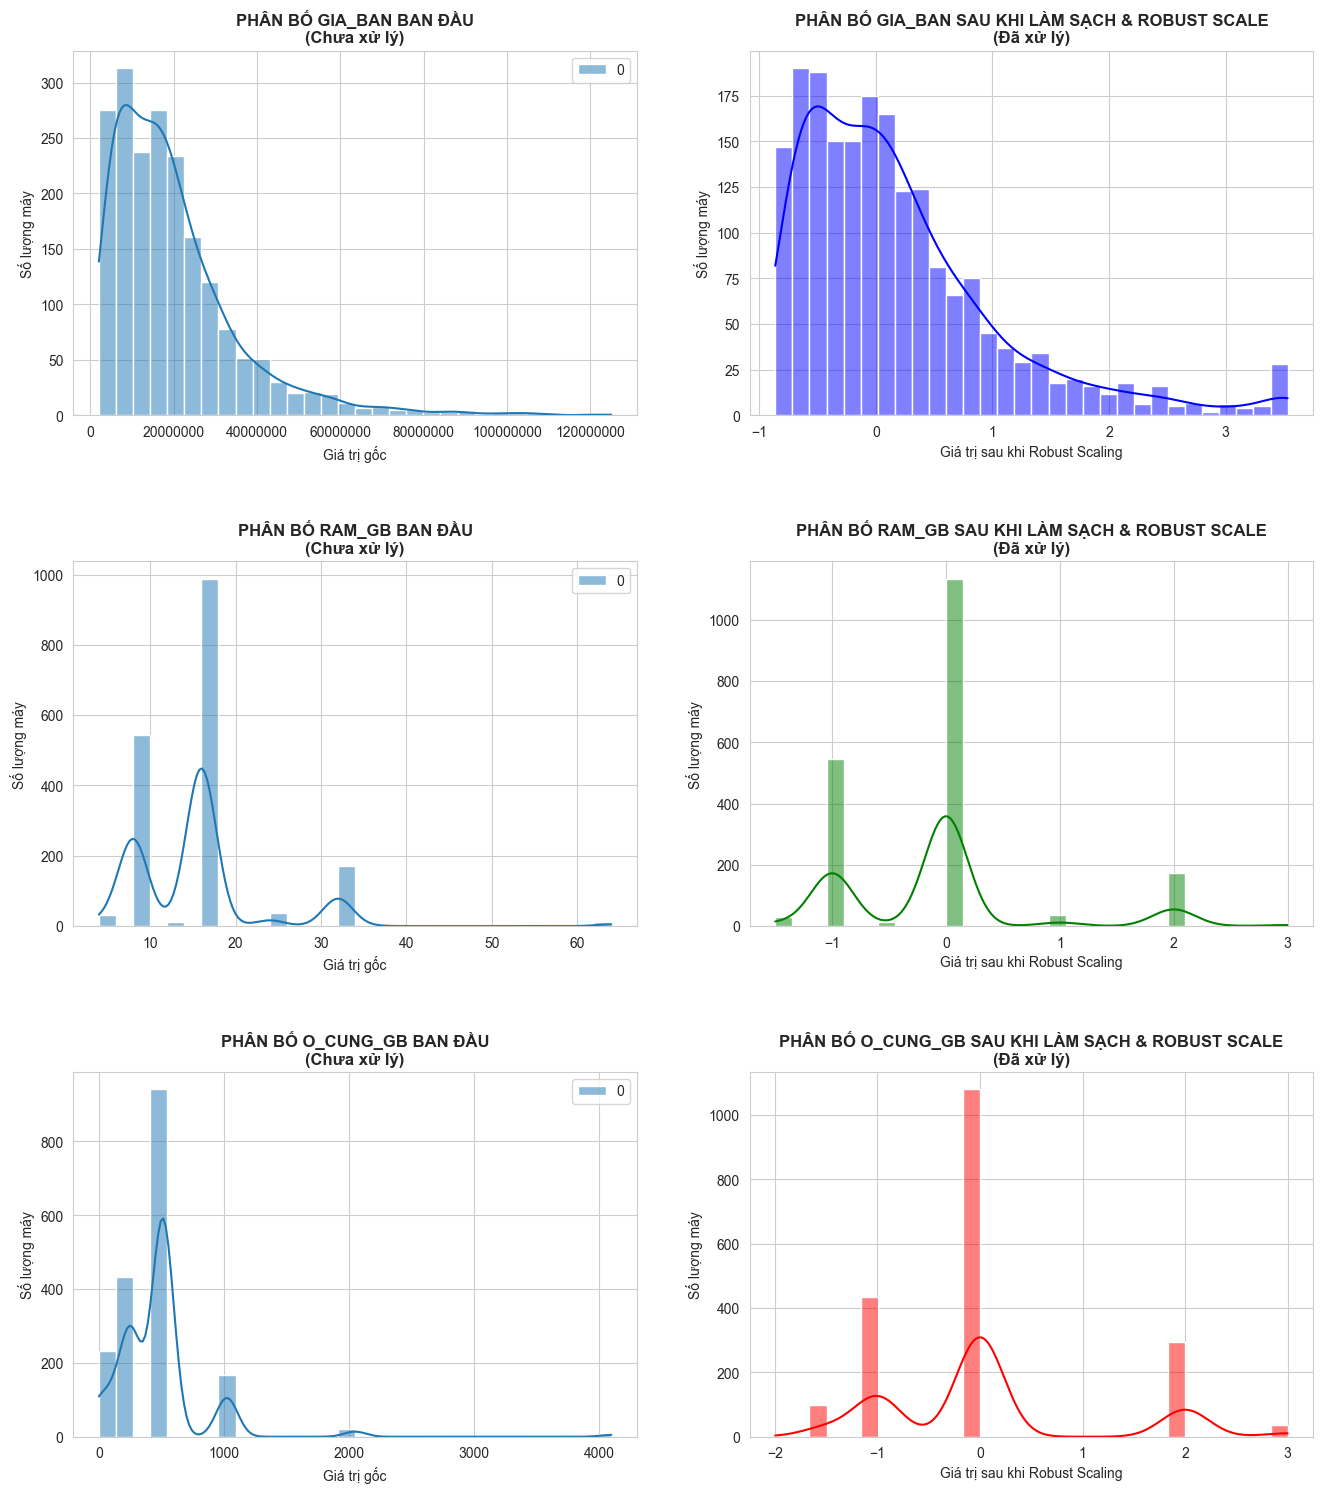

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# 1. ĐỊNH NGHĨA ĐƯỜNG DẪN FILE NGUỒN (Theo ý bạn)
final_clean_path = r'd:\DHBK\KHDL\giuaky\clean data\laptop_robust_scaled.csv'

print("\nFile nguồn mà code này đang sử dụng là:")
print(os.path.abspath(final_clean_path))

# 2. ĐỌC DỮ LIỆU TỪ FILE NÀY ĐỂ SỬ DỤNG
# Giả sử df_outlier_handled là dữ liệu lấy từ file này
df_source = pd.read_csv(final_clean_path)

print('=' * 80)
print('BIỂU ĐỒ SO SÁNH TRƯỚC VÀ SAU KHI LÀM SẠCH & CHUẨN HÓA TỔNG THỂ')
print('=' * 80)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.4)

cols_to_compare = ['gia_ban', 'ram_gb', 'o_cung_gb']
colors = ['blue', 'green', 'red']

for i, col in enumerate(cols_to_compare):
    # Vẽ cột bên trái: Dữ liệu gốc (giả sử lấy từ biến df ban đầu của bạn)
    # Lưu ý: Nếu không còn biến df, bạn phải đọc lại file gốc tại đây
    raw_numeric = df[col].astype(str).str.extract(r'(\d+)').astype(float)
    
    sns.histplot(raw_numeric, kde=True, ax=axes[i, 0], color=colors[i], bins=30)
    axes[i, 0].set_title(f'PHÂN BỐ {col.upper()} BAN ĐẦU\n(Chưa xử lý)', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel('Giá trị gốc')
    axes[i, 0].set_ylabel('Số lượng máy')
    axes[i, 0].ticklabel_format(style='plain', axis='x')

    # Vẽ cột bên phải: Dữ liệu lấy từ file laptop_handled_outliers.csv (df_source)
    # Ở đây tôi dùng df_normalized nếu bạn đã scale, hoặc dùng df_source nếu chỉ muốn xem sau khi xử lý outlier
    sns.histplot(df_normalized[col], kde=True, ax=axes[i, 1], color=colors[i], bins=30)
    axes[i, 1].set_title(f'PHÂN BỐ {col.upper()} SAU KHI LÀM SẠCH & ROBUST SCALE\n(Đã xử lý)', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel('Giá trị sau khi Robust Scaling')
    axes[i, 1].set_ylabel('Số lượng máy')

plt.show()


NHẬN XÉT:
- Đối với biến GIÁ BÁN (GIA_BAN)
Trước xử lý: Biểu đồ bị lệch phải cực kỳ nặng (Right-skewed). Dữ liệu tập trung ở vùng giá thấp nhưng có một cái "đuôi" rất dài kéo đến tận 120 triệu VNĐ. Điều này cho thấy sự hiện diện của các Outliers (ngoại lệ) cực đoan làm nhiễu phân phối chung.
Sau xử lý: Phạm vi dữ liệu đã được thu hẹp lại đáng kể (từ khoảng -1 đến 4 trên thang Robust Scale). Phân phối giờ đây tập trung hơn, giúp các mô hình hồi quy (Regression) không bị "kéo lệch" bởi những chiếc máy quá đắt tiền.
- Đối với biến RAM (RAM_GB)
Trước xử lý: Dữ liệu rời rạc, tập trung ở các mốc 8GB, 16GB nhưng có các ngoại lệ lên đến 64GB khiến biểu đồ bị loãng.
Sau xử lý: Do bạn đã thực hiện Capping (ép biên) và Robust Scaling, các máy có RAM cực khủng đã được kéo về mức biên trên an toàn.
Điểm lưu ý: Cột cao vọt tại vị trí khoảng 2.0 ở biểu đồ sau xử lý chính là nơi các máy RAM lớn (ngoại lệ) được quy tụ lại. Điều này giúp giữ vững tính chất "RAM càng lớn giá càng cao" mà không làm hỏng cấu trúc dữ liệu.
- Đối với biến Ổ CỨNG (O_CUNG_GB)
Trước xử lý: Tương tự RAM, dữ liệu bị phân tán mạnh từ 256GB đến 4000GB. Khoảng trống trắng giữa các mốc 1000GB và 4000GB cho thấy dữ liệu rất thưa thớt ở phân khúc cao cấp.
Sau xử lý: Biểu đồ sau xử lý cho thấy một sự tập trung rất đẹp. Hầu hết dữ liệu nằm quanh mốc 0 (tương ứng với giá trị Trung vị - Median, thường là 512GB).
Hiệu quả: Việc chuẩn hóa giúp mô hình hiểu rằng sự khác biệt giữa 512GB và 1024GB là quan trọng, nhưng sự khác biệt giữa 1024GB và 4000GB (ngoại lệ) nên được kiểm soát để tránh gây sai số lớn.

Mã hóa dữ liệu

In [120]:
import pandas as pd
import os

SOURCE_FILE_PATH = r'd:\DHBK\KHDL\giuaky\clean data\laptop_robust_scaled.csv'
df_to_encode = pd.read_csv(SOURCE_FILE_PATH)

print("\nFile nguồn mà code này đã sử dụng là:")
print(os.path.abspath(SOURCE_FILE_PATH))

print('=' * 50)
print('MÃ HÓA ONE-HOT ENCODING')
print('=' * 50)

# Danh sách các cột phân loại cần mã hóa
categorical_cols = ['thuong_hieu', 'cpu', 'vga']

# Thực hiện One-Hot Encoding trên dữ liệu vừa đọc từ file ổ D
df_final = pd.get_dummies(df_to_encode, columns=categorical_cols, drop_first=True, dtype=int)

print(f"Kích thước dataset cuối cùng: {df_final.shape}")
print(f"Tổng số đặc trưng (features): {len(df_final.columns)}")
print('\n=== 5 DÒNG DỮ LIỆU ĐẦU TIÊN (MÃ HÓA HOÀN TẤT) ===')
display(df_final.head())

# 3. THIẾT LẬP ĐẦU RA (LƯU FILE)
FINAL_DIR = os.path.join('..', 'clean data')
if not os.path.exists(FINAL_DIR):
    os.makedirs(FINAL_DIR, exist_ok=True)

FINAL_OUTPUT_PATH = os.path.join(FINAL_DIR, 'laptop_master_final_processed.csv')
df_final.to_csv(FINAL_OUTPUT_PATH, index=False, encoding='utf-8-sig')

print('\n' + '=' * 50)
print(f'ĐÃ HOÀN TẤT TIỀN XỬ LÝ!')
print(f'File sẵn sàng cho mô hình: {os.path.abspath(FINAL_OUTPUT_PATH)}')
print('=' * 50)




File nguồn mà code này đã sử dụng là:
d:\DHBK\KHDL\giuaky\clean data\laptop_robust_scaled.csv
MÃ HÓA ONE-HOT ENCODING
Kích thước dataset cuối cùng: (1942, 47)
Tổng số đặc trưng (features): 47

=== 5 DÒNG DỮ LIỆU ĐẦU TIÊN (MÃ HÓA HOÀN TẤT) ===


,ten_san_pham,ram_gb,o_cung_gb,gia_ban,cpu_NAN,ram_gb_NAN,o_cung_gb_NAN,vga_NAN,thuong_hieu_ASUS,thuong_hieu_Acer,...,vga_Apple GPU,vga_INTEL ARC GRAPHICS,vga_INTEL GRAPHICS,vga_INTEL IRIS XE,vga_INTEL IRIS XE GRAPHICS,vga_INTEL UHD GRAPHICS,vga_NVIDIA Card Rời,vga_Onboard,vga_Other,vga_RTX 3050 6GB
0,Laptop Msi Prestige 13 AI+ Ukiyoe Edition A2VM...,2.0,3.0,2.129925,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,Laptop Asus Vivobook S14 S3407CA-LY068WS (Ultr...,0.0,0.0,0.689976,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,Laptop Lenovo IdeaPad 3 15ARP10 - 83K700GDVN (...,0.0,0.0,0.204593,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,Laptop Dell 15 DC15250 - CPH99 (i5-1334U/ 16GB...,0.0,0.0,0.155995,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,Laptop HP Victus 15 fa2731TX (B85LNPA) (i5-134...,0.0,0.0,0.689976,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0



ĐÃ HOÀN TẤT TIỀN XỬ LÝ!
File sẵn sàng cho mô hình: d:\DHBK\KHDL\giuaky\clean data\laptop_master_final_processed.csv


Lựa chọn và xây dựng đặc trưng

In [121]:
import pandas as pd
import os

file_path = r'd:\DHBK\KHDL\giuaky\clean data\laptop_master_final_processed.csv'

print('=' * 50)
print('XÂY DỰNG ĐẶC TRƯNG')
print('=' * 50)

if os.path.exists(file_path):
    df_work = pd.read_csv(file_path)
    print(f"Thành công! Đã kết nối với dữ liệu tại: \n{file_path}")
else:
    print(f"Vẫn không tìm thấy file!")

if 'df_work' in locals():
    df_work['is_high_perf_cpu'] = df_work['ten_san_pham'].str.contains(r'[0-9]+(H|HS|HX)', case=True, na=False).astype(int)
    df_work['is_gaming_vga'] = df_work['ten_san_pham'].str.contains('RTX|GTX|Radeon|Card Rời', case=False, na=False).astype(int)
    df_work['is_premium_screen'] = df_work['ten_san_pham'].str.contains('OLED|4K|UHD|Retina|2K|WQXGA', case=False, na=False).astype(int)
    df_work['is_luxury_line'] = df_work['ten_san_pham'].str.contains('Macbook|Zenbook|Spectre|XPS|Prestige|Gram', case=False, na=False).astype(int)
    cols_to_show = ['ten_san_pham', 'gia_ban','o_cung_gb', 'ram_gb', 'is_high_perf_cpu', 'is_gaming_vga', 'is_premium_screen', 'is_luxury_line']
    cols_final = ['gia_ban', 'ram_gb', 'o_cung_gb', 'is_high_perf_cpu', 'is_gaming_vga', 'is_premium_screen', 'is_luxury_line']

    df_ready = df_work[cols_final]

    display(df_work[cols_to_show].head(10))
    print('\nThống kê mô tả (Check đơn vị gia_ban):')
    display(df_ready.describe())

XÂY DỰNG ĐẶC TRƯNG
Thành công! Đã kết nối với dữ liệu tại: 
d:\DHBK\KHDL\giuaky\clean data\laptop_master_final_processed.csv


,ten_san_pham,gia_ban,o_cung_gb,ram_gb,is_high_perf_cpu,is_gaming_vga,is_premium_screen,is_luxury_line
0,Laptop Msi Prestige 13 AI+ Ukiyoe Edition A2VM...,2.129925,3.0,2.0,0,0,0,1
1,Laptop Asus Vivobook S14 S3407CA-LY068WS (Ultr...,0.689976,0.0,0.0,1,0,0,0
2,Laptop Lenovo IdeaPad 3 15ARP10 - 83K700GDVN (...,0.204593,0.0,0.0,1,0,0,0
3,Laptop Dell 15 DC15250 - CPH99 (i5-1334U/ 16GB...,0.155995,0.0,0.0,0,0,0,0
4,Laptop HP Victus 15 fa2731TX (B85LNPA) (i5-134...,0.689976,0.0,0.0,1,1,0,0
5,Laptop Asus ROG Zephyrus G16 GU605CR-QR265WS (...,3.532616,2.0,2.0,1,1,0,0
6,Laptop Asus Expertbook B1 BM1403CDA-S61611W (R...,0.017999,0.0,0.0,0,0,0,0
7,Laptop HP 15-fc0024AU - D0BH2PA (Ryzen 5 7520U...,0.006000,0.0,0.0,0,0,0,0
8,Laptop Lenovo ThinkPad T16 Gen 4 - 21QE000DVN ...,1.637943,2.0,2.0,1,0,0,0
9,Laptop Lenovo ThinkPad X1 Carbon Gen 13 - 21NS...,2.783903,2.0,2.0,0,0,0,0



Thống kê mô tả (Check đơn vị gia_ban):


,gia_ban,ram_gb,o_cung_gb,is_high_perf_cpu,is_gaming_vga,is_premium_screen,is_luxury_line
count,1942.000000,1942.000000,1942.000000,1942.000000,1942.000000,1942.000000,1942.000000
mean,0.193403,-0.091916,0.057890,0.323893,0.167353,0.102987,0.144696
std,0.883722,0.860084,1.055227,0.468080,0.373387,0.304020,0.351885
min,-0.863370,-1.500000,-1.996094,0.000000,0.000000,0.000000,0.000000
25%,-0.467384,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.532616,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,3.532616,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


Trực quan hóa đa biến


File nguồn mà code này đang sử dụng là:
d:\DHBK\KHDL\giuaky\clean data\laptop_master_final_processed.csv
6. TRỰC QUAN HÓA ĐA BIẾN (MULTIVARIATE ANALYSIS)


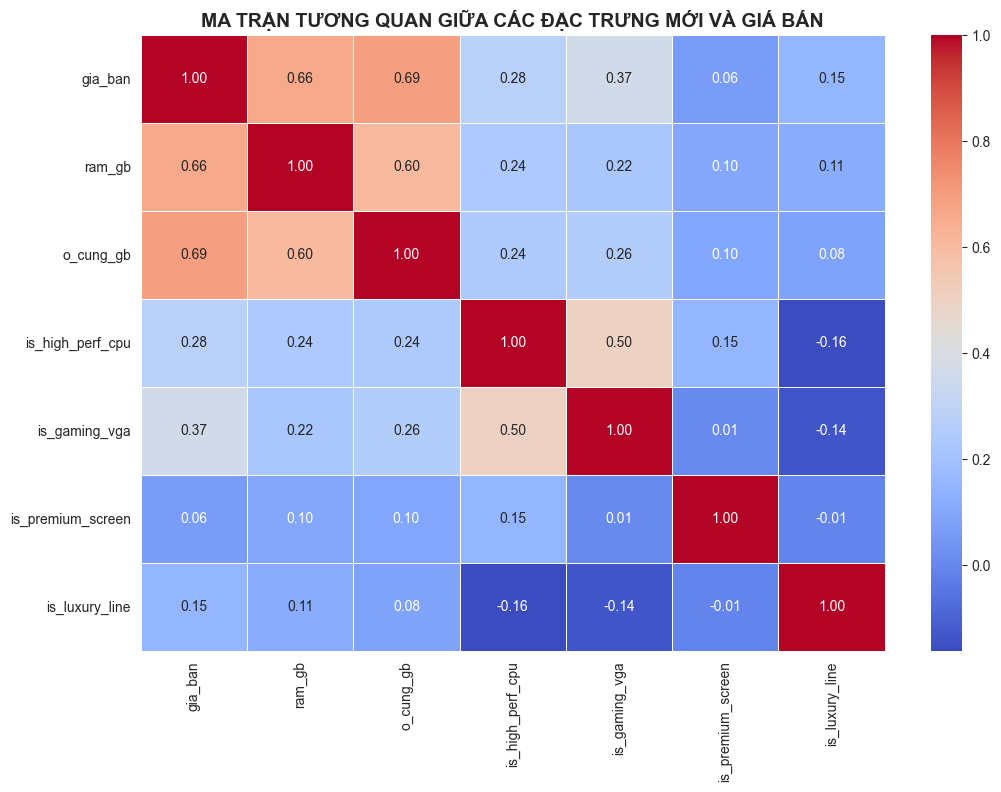

In [123]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. ĐỊNH NGHĨA ĐƯỜNG DẪN FILE (Sử dụng file bạn đã xử lý ở bước trước)
FINAL_PROCESSED_PATH = r'd:\DHBK\KHDL\giuaky\clean data\laptop_master_final_processed.csv'
print("\nFile nguồn mà code này đang sử dụng là:")
print(os.path.abspath(FINAL_PROCESSED_PATH))

if 'df_ready' not in locals():
    df_work = pd.read_csv(FINAL_PROCESSED_PATH)
    # Lặp lại logic tạo đặc trưng của bạn để có dữ liệu vẽ
    df_work['is_high_perf_cpu'] = df_work['ten_san_pham'].str.contains(r'[0-9]+(H|HS|HX)', case=True, na=False).astype(int)
    df_work['is_gaming_vga'] = df_work['ten_san_pham'].str.contains('RTX|GTX|Radeon|Card Rời', case=False, na=False).astype(int)
    df_work['is_premium_screen'] = df_work['ten_san_pham'].str.contains('OLED|4K|UHD|Retina|2K|WQXGA', case=False, na=False).astype(int)
    df_work['is_luxury_line'] = df_work['ten_san_pham'].str.contains('Macbook|Zenbook|Spectre|XPS|Prestige|Gram', case=False, na=False).astype(int)
    cols_final = ['gia_ban', 'ram_gb', 'o_cung_gb', 'is_high_perf_cpu', 'is_gaming_vga', 'is_premium_screen', 'is_luxury_line']
    df_ready = df_work[cols_final]

print('=' * 50)
print('6. TRỰC QUAN HÓA ĐA BIẾN (MULTIVARIATE ANALYSIS)')
print('=' * 50)

# 3. VẼ MA TRẬN TƯƠNG QUAN TRÊN CÁC ĐẶC TRƯNG MỚI
plt.figure(figsize=(12, 8))

# Tính toán tương quan (numeric_only=True để đảm bảo an toàn)
corr = df_ready.corr(numeric_only=True)

# Giữ nguyên logic heatmap của bạn
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('MA TRẬN TƯƠNG QUAN GIỮA CÁC ĐẶC TRƯNG MỚI VÀ GIÁ BÁN', fontsize=14, fontweight='bold')
plt.show()



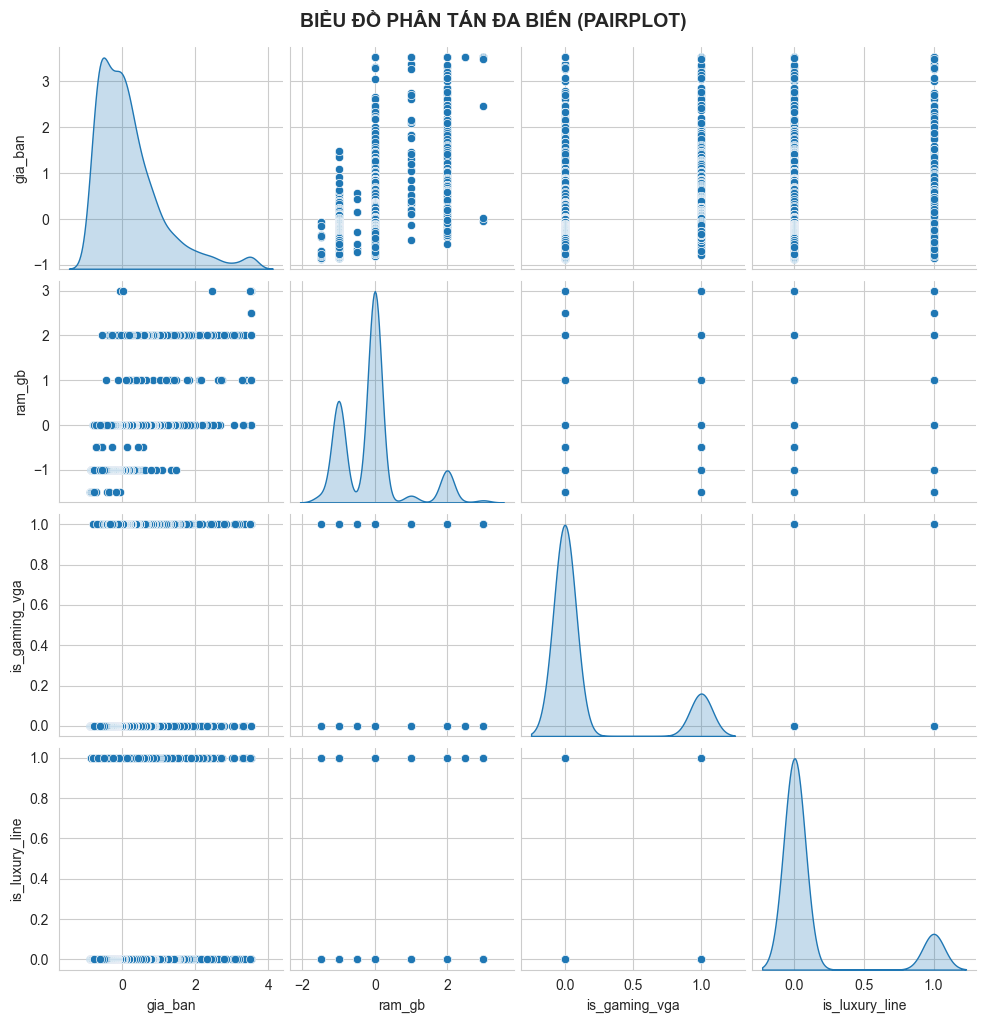

In [124]:
main_features = ['gia_ban', 'ram_gb', 'is_gaming_vga', 'is_luxury_line']
sns.pairplot(df_ready[main_features], diag_kind='kde', height=2.5)
plt.suptitle('BIỂU ĐỒ PHÂN TÁN ĐA BIẾN (PAIRPLOT)', y=1.02, fontsize=14, fontweight='bold')
plt.show()


Clustermap 

In [111]:
import sys
!{sys.executable} -m pip install scipy

VẼ CLUSTERMAP: NHÓM CÁC ĐẶC TRƯNG TƯƠNG QUAN


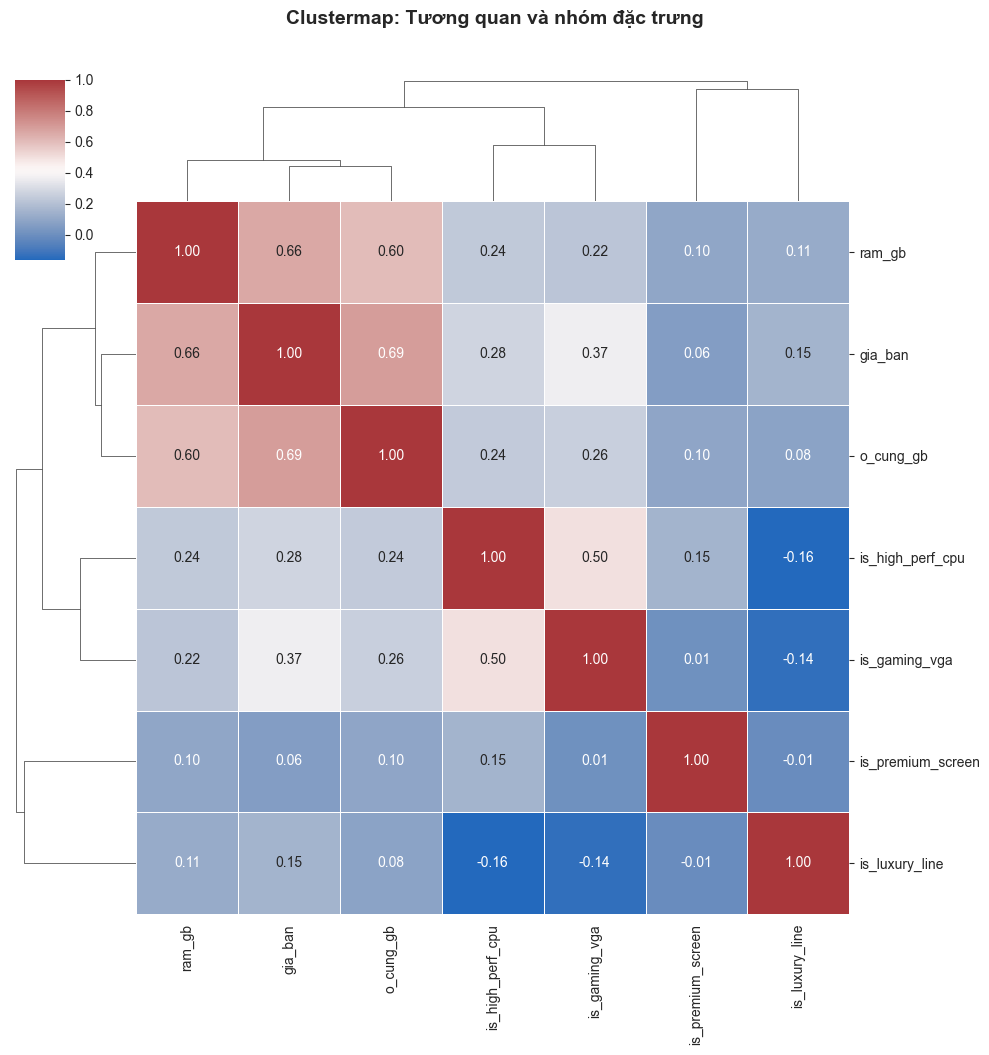


File nguồn mà code này đang sử dụng là:
d:\DHBK\KHDL\giuaky\clean data\laptop_master_final_processed.csv


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
try:
    cols_final = ['gia_ban', 'ram_gb', 'o_cung_gb', 'is_high_perf_cpu', 'is_gaming_vga', 'is_premium_screen', 'is_luxury_line']
    df_ready = df_work[cols_final]
    
    print('=' * 50)
    print('VẼ CLUSTERMAP: NHÓM CÁC ĐẶC TRƯNG TƯƠNG QUAN')
    print('=' * 50)
    corr = df_ready.corr()

    g = sns.clustermap(corr, 
                       annot=True, 
                       cmap='vlag', 
                       fmt='.2f', 
                       figsize=(10, 10), 
                       linewidths=0.5,
                       dendrogram_ratio=0.15)

    g.fig.suptitle('Clustermap: Tương quan và nhóm đặc trưng', fontsize=14, fontweight='bold', y=1.05)
    plt.show()

except NameError as e:
    print(f"Lỗi: {e}")

# PHẦN IN THÔNG TIN ĐƯỜNG DẪN
print("\nFile nguồn mà code này đang sử dụng là:")
print(os.path.abspath(FINAL_PROCESSED_PATH))


File nguồn mà code này đang sử dụng là:
d:\DHBK\KHDL\giuaky\clean data\laptop_master_final_processed.csv
7. PHÂN TÍCH THÀNH PHẦN CHÍNH (PCA) - KHÁM PHÁ CẤU TRÚC
Tổng phương sai được giải thích bởi 2 thành phần PCA: 48.78%


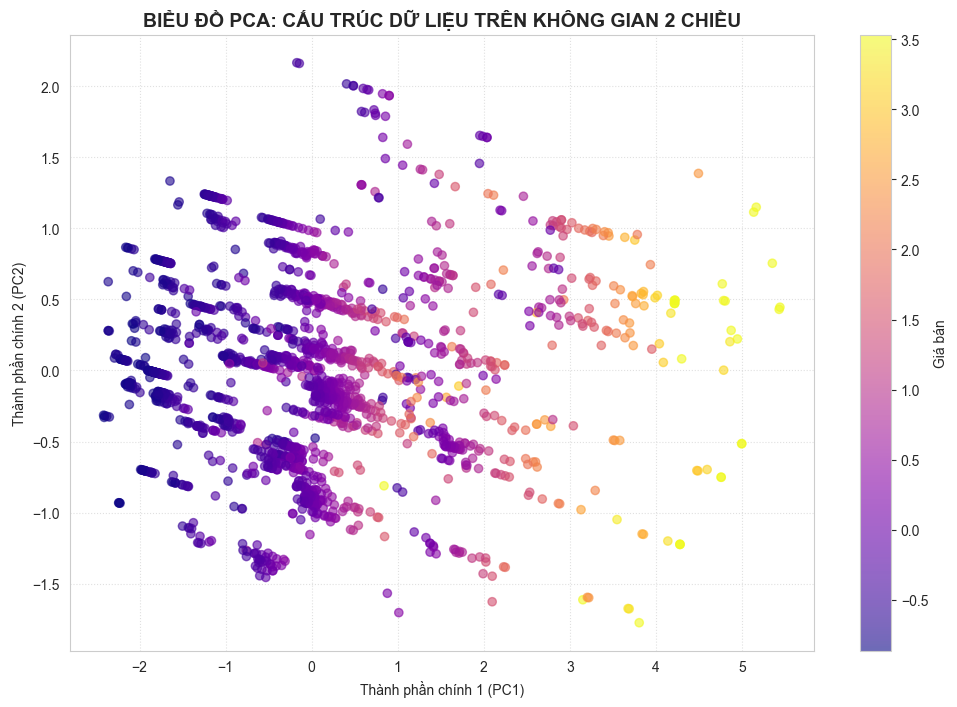

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import os

# Đường dẫn tương đối từ file notebook vào folder clean data
path = os.path.join('..', 'clean data', 'laptop_master_final_processed.csv')
df_processed = pd.read_csv(path)

print("\nFile nguồn mà code này đang sử dụng là:")
print(os.path.abspath(FINAL_PROCESSED_PATH))

# Loại bỏ cột tên sản phẩm (chuỗi) để tính toán PCA
X = df_final.drop(columns=['ten_san_pham'])

print('=' * 50)
print('7. PHÂN TÍCH THÀNH PHẦN CHÍNH (PCA) - KHÁM PHÁ CẤU TRÚC')
print('=' * 50)

# 2. Thực hiện PCA để giảm về 2 chiều
pca = PCA(n_components=2)
components = pca.fit_transform(X)

# Tạo DataFrame cho kết quả PCA
df_pca = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
df_pca['gia_ban'] = df_final['gia_ban'] # Giữ lại giá để tô màu

# 3. Trực quan hóa kết quả PCA
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], 
            c=df_pca['gia_ban'], cmap='plasma', alpha=0.6)

plt.colorbar(scatter, label='Giá bán')
plt.title('BIỂU ĐỒ PCA: CẤU TRÚC DỮ LIỆU TRÊN KHÔNG GIAN 2 CHIỀU', fontsize=14, fontweight='bold')
plt.xlabel('Thành phần chính 1 (PC1)')
plt.ylabel('Thành phần chính 2 (PC2)')
plt.grid(True, linestyle=':', alpha=0.6)

# 4. Kiểm tra phương sai tích lũy
exp_var = pca.explained_variance_ratio_
print(f"Tổng phương sai được giải thích bởi 2 thành phần PCA: {sum(exp_var)*100:.2f}%")

Biểu đồ Pairplot cho thấy sự đồng nhất và quy luật rõ rệt giữa các biến số cấu hình và giá bán. Việc dữ liệu đã được làm sạch hoàn toàn khỏi các giá trị ngoại lệ cực đoan giúp giảm thiểu nhiễu


File nguồn mà code này đang sử dụng là:
d:\DHBK\KHDL\giuaky\clean data\laptop_master_final_processed.csv
6. PHÂN TÍCH ĐA BIẾN: MỐI QUAN HỆ RAM - VGA (DỮ LIỆU SẠCH)


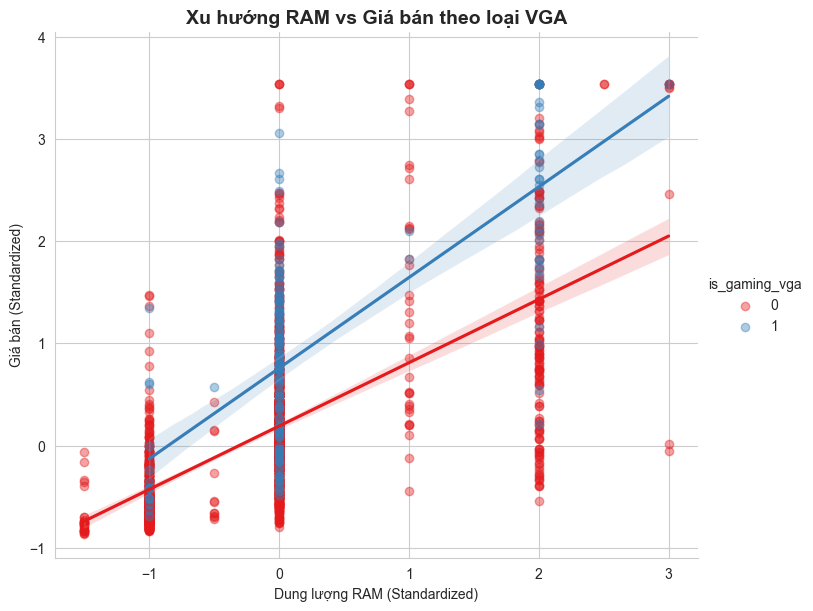

In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Đường dẫn tương đối từ file notebook vào folder clean data
path = os.path.join('..', 'clean data', 'laptop_master_final_processed.csv')
df_processed = pd.read_csv(path)

print("\nFile nguồn mà code này đang sử dụng là:")
print(os.path.abspath(FINAL_PROCESSED_PATH))

# 2. Tái tạo cột is_gaming_vga từ các cột One-Hot để làm màu (hue)
# Ta kiểm tra nếu máy có NVIDIA Card Rời hoặc RTX 3050 thì coi là Gaming
if 'vga_NVIDIA Card Rời' in df_processed.columns:
    df_processed['is_gaming_vga'] = df_processed['vga_NVIDIA Card Rời']
else:
    # Nếu không tìm thấy cột cụ thể, ta quét tên sản phẩm để xác định
    df_processed['is_gaming_vga'] = df_processed['ten_san_pham'].str.contains('RTX|GTX|Radeon|Card Rời', case=False, na=False).astype(int)

print('=' * 50)
print('6. PHÂN TÍCH ĐA BIẾN: MỐI QUAN HỆ RAM - VGA (DỮ LIỆU SẠCH)')
print('=' * 50)

# 3. Vẽ lmplot trên dữ liệu đã chuẩn hóa (Standardized)
# Lưu ý: Trục Y lúc này sẽ chạy từ -1 đến khoảng 4.5 (Không còn 120,000,000)
g = sns.lmplot(data=df_processed, x='ram_gb', y='gia_ban', hue='is_gaming_vga', 
               palette='Set1', height=6, aspect=1.2, scatter_kws={'alpha':0.4})

# 4. Trang trí biểu đồ
plt.title('Xu hướng RAM vs Giá bán theo loại VGA', fontsize=14, fontweight='bold')
plt.xlabel('Dung lượng RAM (Standardized)')
plt.ylabel('Giá bán (Standardized)')

# Bỏ dòng ticklabel_format(style='plain') vì số lúc này rất nhỏ, không cần định dạng số lớn
plt.show()


File nguồn mà code này đang sử dụng là:
d:\DHBK\KHDL\giuaky\clean data\laptop_master_final_processed.csv
8. TRỰC QUAN HÓA T-SNE: KHÁM PHÁ CÁC CỤM DỮ LIỆU TỰ NHIÊN


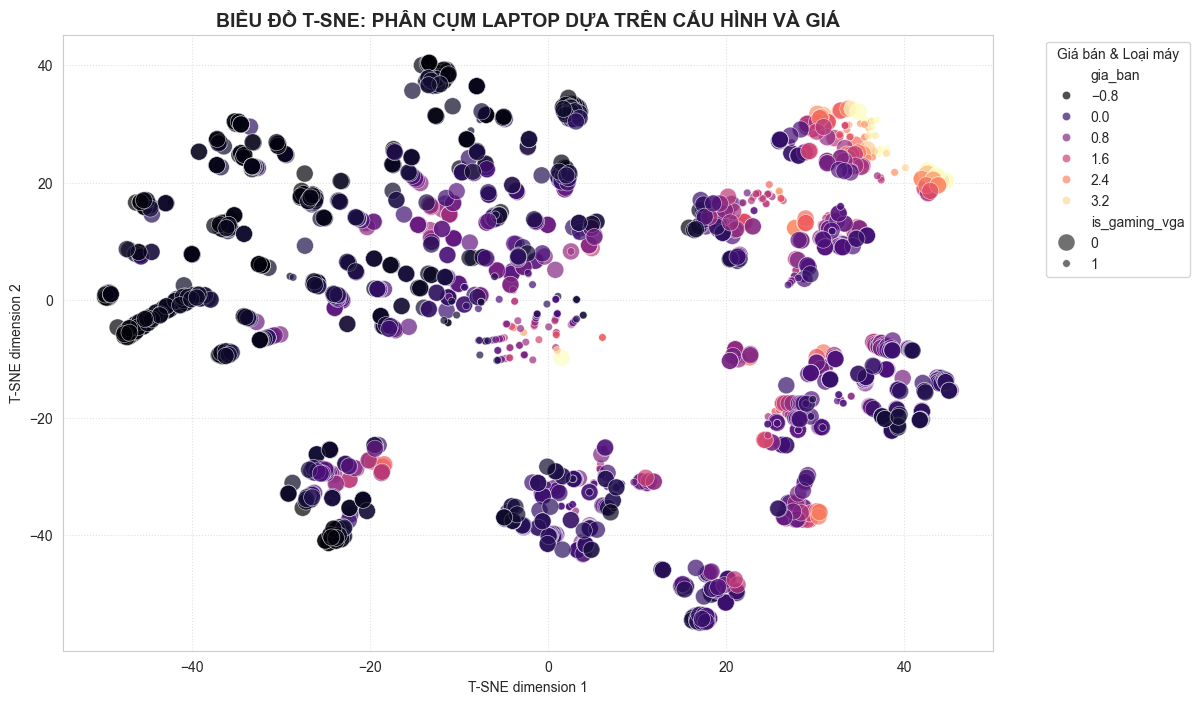

In [128]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu (Sử dụng df_final đã One-Hot Encoding và Scaling)
# Loại bỏ cột 'ten_san_pham' vì t-SNE chỉ làm việc với số
X_tsne = df_final.drop(columns=['ten_san_pham']) 

print("\nFile nguồn mà code này đang sử dụng là:")
print(os.path.abspath(FINAL_PROCESSED_PATH))


print('=' * 50)
print('8. TRỰC QUAN HÓA T-SNE: KHÁM PHÁ CÁC CỤM DỮ LIỆU TỰ NHIÊN')
print('=' * 50)

# 2. Thực hiện t-SNE để giảm về 2 chiều
# perplexity: số lượng láng giềng gần (thường từ 5 đến 50)
tsne = TSNE(n_components=2, perplexity=35, learning_rate='auto', init='pca', random_state=42)
X_embedded = tsne.fit_transform(X_tsne)

# Tạo DataFrame cho kết quả t-SNE
df_tsne = pd.DataFrame(data=X_embedded, columns=['TSNE1', 'TSNE2'])
df_tsne['gia_ban'] = df_final['gia_ban']

# Lấy thêm thông tin Gaming từ df_ready để làm kích thước điểm (size) cho sinh động
if 'is_gaming_vga' in df_ready.columns:
    df_tsne['is_gaming_vga'] = df_ready['is_gaming_vga']

# 3. Trực quan hóa kết quả t-SNE
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', 
                          hue='gia_ban', size='is_gaming_vga',
                          palette='magma', alpha=0.7, sizes=(30, 150))

plt.title('BIỂU ĐỒ T-SNE: PHÂN CỤM LAPTOP DỰA TRÊN CẤU HÌNH VÀ GIÁ', fontsize=14, fontweight='bold')
plt.xlabel('T-SNE dimension 1')
plt.ylabel('T-SNE dimension 2')
plt.legend(title='Giá bán & Loại máy', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

NHẬN XÉT:

Độ tương quan RAM - Giá bán (theo VGA)
Cả hai đường hồi quy (màu đỏ và màu xanh) đều có độ dốc hướng lên rõ rệt. Điều này khẳng định RAM là biến số quan trọng nhất tỉ lệ thuận với giá trị laptop. 
Sự phân tách giá trị: Đường hồi quy của nhóm có VGA rời (is_gaming_vga = 1) nằm cao hơn hẳn nhóm Onboard. Điều này cho thấy VGA rời đóng vai trò là một "hệ số cộng thêm" đáng kể vào giá trị máy.
Độ phân tán đặc trưng (Data Distribution):
Nhóm Onboard (Màu đỏ): Tập trung cực kỳ dày đặc ở vùng RAM thấp (quanh mức 0.0). Đây là vùng an toàn của phân khúc văn phòng, giá biến động ít.
Nhóm Gaming (Màu xanh): Dữ liệu trải dài sang bên phải trục X (RAM cao) và vọt lên trên trục Y (Giá cao). Điều này minh chứng cho sự đa dạng cấu hình của dòng máy chuyên dụng.


KẾT LUẬN:

- Qua quá trình thu thập, phân tích và xử lý dữ liệu, có thể rút ra các kết luận chính như sau:
Bài toán đặt ra là dự đoán giá bán sản phẩm (Y) dựa trên các đặc trưng kỹ thuật như RAM, CPU, GPU, thương hiệu,… Do biến mục tiêu Y là biến số liên tục nên đây là bài toán hồi quy (Regression).
Tập dữ liệu được thu thập từ nhiều nguồn thương mại điện tử với số lượng mẫu lớn (trên 1000 mẫu) và số lượng đặc trưng đa dạng (>5), đảm bảo đủ thông tin để phục vụ cho việc xây dựng mô hình.
Thông qua các bước phân tích và trực quan hóa:
Quan sát được sự phân bố của biến giá có xu hướng lệch (skewed).
Một số đặc trưng như RAM, CPU, GPU thể hiện mối quan hệ rõ ràng với giá bán.
Ma trận tương quan và các biểu đồ đa biến cho thấy tồn tại mối quan hệ tiềm ẩn giữa các biến đầu vào và biến mục tiêu.

- Sau quá trình làm sạch dữ liệu:
Dữ liệu đã được xử lý giá trị thiếu, loại bỏ hoặc điều chỉnh outliers.
Phân phối dữ liệu trở nên ổn định và phù hợp hơn cho việc học máy.
Các kỹ thuật chuẩn hóa và mã hóa dữ liệu đã được áp dụng giúp chuyển đổi dữ liệu về dạng phù hợp cho mô hình.
Từ các phân tích trên, có thể kết luận rằng:
Bài toán là khả thi về mặt dữ liệu, và tập dữ liệu hiện tại hoàn toàn có thể sử dụng để xây dựng mô hình dự đoán.
Các đặc trưng quan trọng có thể sử dụng để xây dựng mô hình bao gồm:
RAM
CPU
GPU
Thương hiệu
Các thông số kỹ thuật khác (nếu có)

TÀI LIỆU THAM KHẢO: 
- Slide chương 5 : Xử lý dữ liệu của  (p1, p2) Ninh Khánh Duy 
- Seaborn Visualization Library: https://seaborn.pydata.org/